# Create Training Labels from the TA2 Extraction for Conterminous U.S.
from CSV to GeoTIFF


In [13]:
import numpy as np

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

from beak.experimental.io import load_raster, load_dataset


### **Load** data

**User definitions**

In [14]:
BASE_PATH = files("beak.data")
PATH_LABELS = BASE_PATH / "CRITICAL_MINERAL_DEPOSITS" / "Magmatic_Nickel" / "hypersite_nickel_us_data.csv"
PATH_BASE_RASTER = BASE_PATH / "BASE_RASTERS" / "EPSG_4326_RES_0_025_US_CONT.tif"


**Load** dataset

In [15]:
mineral_sites = load_dataset(PATH_LABELS)

### **Investigate**

Histogram mineral sites complete data set

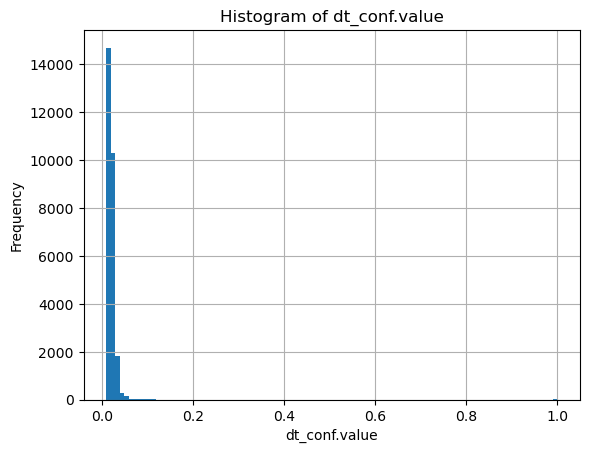

In [16]:
import matplotlib.pyplot as plt

mineral_sites['dt_conf.value'].hist(bins=100)
plt.xlabel("dt_conf.value")
plt.ylabel("Frequency")
plt.title("Histogram of dt_conf.value")
plt.show()


Histogram mineral sites unique locations with maximum confidence

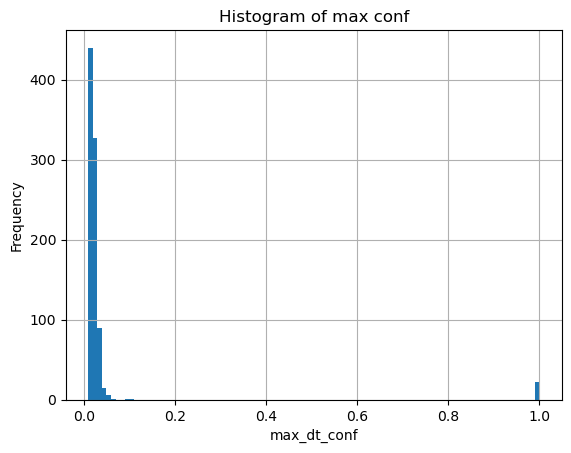

In [17]:
mineral_sites["max_dt_conf"] = mineral_sites.groupby("loc_wkt.value")["dt_conf.value"].transform("max")

# Unique Locations
mineral_sites_filtered = mineral_sites.drop_duplicates(subset="loc_wkt.value")
len(mineral_sites_filtered)

import matplotlib.pyplot as plt

mineral_sites_filtered["max_dt_conf"].hist(bins=100)
plt.xlabel("max_dt_conf")
plt.ylabel("Frequency")
plt.title("Histogram of max conf")
plt.show()

### **Filter** relevant data according to agreements on hackathon 6M

**Remove** ophiolites

In [18]:
filtered_mineral_sites_oph = mineral_sites[mineral_sites["dtnorm_label.value"] != "Ophiolite nickel-copper-PGE"]
len(filtered_mineral_sites_oph)


22224

**Cut** at confidence threshold

In [19]:
filtered_mineral_sites_oph_conf = filtered_mineral_sites_oph[filtered_mineral_sites_oph["dt_conf.value"] >= 0.025]
len(filtered_mineral_sites_oph_conf)


3585

**Remove** spatial duplicates

In [20]:
mineral_sites_filtered_final = filtered_mineral_sites_oph_conf.drop_duplicates(subset="loc_wkt.value")
len(mineral_sites_filtered_final)

172

**Check** results

In [21]:
mineral_sites_filtered_final.head()

,Unnamed: 0.1,ms.value,dt_conf.value,dt_s.value,dtnorm.value,dtnorm_label.value,country.value,loc_wkt.value,oms.value,Unnamed: 0,source,source_id,prediction,ms_record_id.value,ms_source_id.value,site_hyper_id,max_dt_conf
0,0,https://minmod.isi.edu/resource/mrds10056259,0.032008,"algorithm predictions, SRI deposit type classi...",https://minmod.isi.edu/resource/Q486,Arc U-M intru- sion nickel- copper-PGE,United States,POINT (-109.79635 45.35242),https://minmod.isi.edu/resource/mrds10048508,770.0,MRDS,10056259,1442.0,10056259,MRDS,https://minmod.isi.edu/resource/1442,0.032008
20,20,https://minmod.isi.edu/resource/mrds10197903,0.028549,"algorithm predictions, SRI deposit type classi...",https://minmod.isi.edu/resource/Q486,Arc U-M intru- sion nickel- copper-PGE,United States,POINT (-114.14251 36.62439),NaN,1946.0,MRDS,10197903,311.0,10197903,MRDS,https://minmod.isi.edu/resource/311,0.035864
116,116,https://minmod.isi.edu/resource/mrds10136902,0.030263,"algorithm predictions, SRI deposit type classi...",https://minmod.isi.edu/resource/Q482,U-M conduit nickel-copper- PGE,United States,POINT (-135.0381 57.79693),NaN,1619.0,MRDS,10136902,1414.0,10136902,MRDS,https://minmod.isi.edu/resource/1414,0.030263
437,437,https://minmod.isi.edu/resource/mrds10056251,0.035008,"algorithm predictions, SRI deposit type classi...",https://minmod.isi.edu/resource/Q486,Arc U-M intru- sion nickel- copper-PGE,United States,POINT (-110.16941 45.47103),https://minmod.isi.edu/resource/mrds10042345,763.0,MRDS,10056251,819.0,10056251,MRDS,https://minmod.isi.edu/resource/819,0.035008
472,472,https://minmod.isi.edu/resource/mrds10282983,0.036132,"algorithm predictions, SRI deposit type classi...",https://minmod.isi.edu/resource/Q476,Komatiite nickel-copper-PGE,United States,POINT (-136.47095 57.88301),NaN,2503.0,MRDS,10282983,732.0,10282983,MRDS,https://minmod.isi.edu/resource/732,0.036132


It still looks like that there are a few duplicates remaining due to rounding errors. <p>
We will not remove them at this point since they will be aggregated in the rasterization process anyway. <p>
There are also some `Multipoint` geometries that do not work proberly with the rasterization process. <p>

**Write** results to file

In [22]:
# Save the final filtered dataset to csv
save = False

if save:
  mineral_sites_filtered_final.to_csv("04_ta2_mineral_sites_filtered_final.csv", index=False)


# Create Labels

Create labels array

In [23]:
import geopandas as gpd
from rasterio.crs import CRS
from shapely import wkt

from beak.experimental.conversions import create_binary_raster

crs = CRS.from_epsg(4326)
data = mineral_sites_filtered_final.copy()

# That row is necessary due to some Multipoint features that have to be converted to Points
data["geometry"] = data["loc_wkt.value"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(data, geometry="geometry", crs=crs)

base_raster = load_raster(PATH_BASE_RASTER)
out_path = BASE_PATH / "TRAINING_LABELS" / "MAGMATIC_NICKEL_NAT" / "MAGMATIC_NICKEL_TA2_EPSG_4326_RES_0_025_US_CONT.tif"


Save to file

In [24]:
# Replace out_file=None with out_file=out_path to save the output raster
out_array = create_binary_raster(gdf, base_raster, all_touched=False, same_shape=True, fill_negatives=True, out_file=None)

# Check results
np.unique(out_array, return_counts=True)

(array([-99,   0,   1], dtype=int8),
 array([1063214, 1336193,     109], dtype=int64))